Downloading/Loading MNIST dataset...

Starting Experiments...



EXPERIMENT SUMMARY TABLE
          Config Output Dim  Params  Time (s)  Accuracy
Valid | Stride 1      26x26   54410      5.13    0.9640
Same  | Stride 1      28x28   63050      4.55    0.9685
Valid | Stride 2      13x13   11850      4.62    0.9460
Same  | Stride 2      14x14   16010      4.91    0.9431


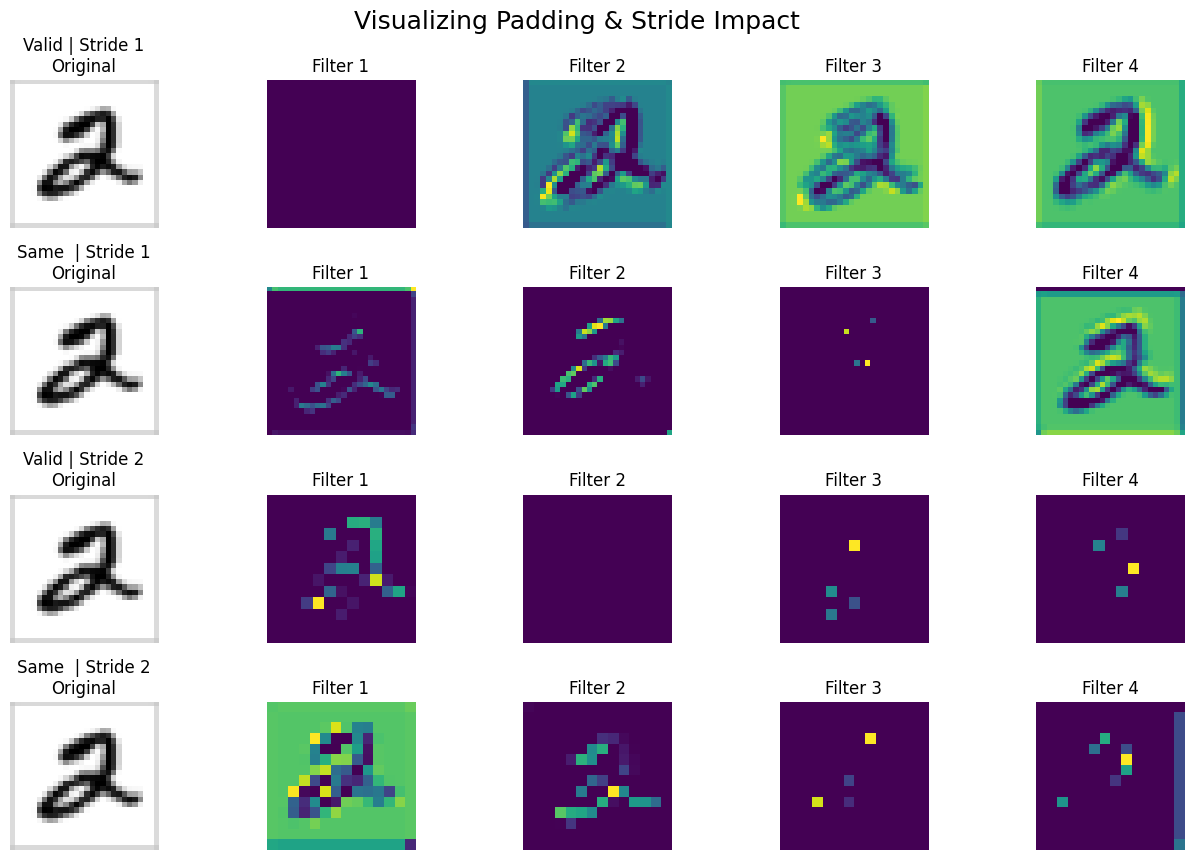

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from PIL import Image

def run_experiments():
    """Main function to load data, iterate through CNN configs, and plot results."""

    # ---------------------------------------------------------
    # 1. LOAD AND PREPROCESS DATA
    # ---------------------------------------------------------
    print("Downloading/Loading MNIST dataset...")
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

    y_train = keras.utils.to_categorical(y_train, 10)
    y_test = keras.utils.to_categorical(y_test, 10)

    # ---------------------------------------------------------
    # LOAD YOUR CUSTOM IMAGE
    # ---------------------------------------------------------
    img = Image.open("computer - vision /Lab-3/cnn_experiment/images.jpeg").convert("L")
    img = img.resize((28,28))
    img = np.array(img)

    img = img.astype("float32") / 255.0
    sample_digit = img.reshape(1,28,28,1)

    # ---------------------------------------------------------
    # 2. DEFINE EXPERIMENT CONFIGURATIONS
    # ---------------------------------------------------------
    configs = [
        {"padding": "valid", "stride": 1, "name": "Valid | Stride 1"},
        {"padding": "same",  "stride": 1, "name": "Same  | Stride 1"},
        {"padding": "valid", "stride": 2, "name": "Valid | Stride 2"},
        {"padding": "same",  "stride": 2, "name": "Same  | Stride 2"}
    ]

    results = []
    feature_maps_to_plot = []

    print("\nStarting Experiments...")
    for config in configs:

        inputs = layers.Input(shape=(28, 28, 1))

        conv_layer = layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding=config['padding'],
            strides=config['stride'],
            activation='relu',
            name='target_conv'
        )(inputs)

        intermediate_model = keras.Model(inputs=inputs, outputs=conv_layer)

        x = layers.MaxPooling2D((2, 2))(conv_layer)
        x = layers.Flatten()(x)
        outputs = layers.Dense(10, activation='softmax')(x)

        model = keras.Model(inputs=inputs, outputs=outputs)

        # Extract feature maps
        maps = intermediate_model.predict(sample_digit, verbose=0)
        out_shape = maps.shape[1:3]
        params = model.count_params()

        model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        start = time.time()

        model.fit(x_train, y_train,
                  epochs=2,
                  batch_size=256,
                  verbose=0)

        train_time = round(time.time() - start, 2)

        _, acc = model.evaluate(x_test, y_test, verbose=0)

        results.append({
            "Config": config['name'],
            "Output Dim": f"{out_shape[0]}x{out_shape[1]}",
            "Params": params,
            "Time (s)": train_time,
            "Accuracy": round(acc, 4)
        })

        feature_maps_to_plot.append((maps, config['name']))

    # ---------------------------------------------------------
    # 3. PRINT RESULT TABLE
    # ---------------------------------------------------------
    print("\n" + "="*60)
    print("EXPERIMENT SUMMARY TABLE")
    print("="*60)

    print(pd.DataFrame(results).to_string(index=False))

    # ---------------------------------------------------------
    # 4. VISUALIZATION
    # ---------------------------------------------------------
    fig, axes = plt.subplots(4, 5, figsize=(16, 10))
    plt.subplots_adjust(hspace=0.4)

    for i, (maps, name) in enumerate(feature_maps_to_plot):

        axes[i, 0].imshow(sample_digit[0, :, :, 0], cmap='gray')
        axes[i, 0].set_title(f"{name}\nOriginal")
        axes[i, 0].axis('off')

        for j in range(1, 5):
            axes[i, j].imshow(maps[0, :, :, j], cmap='viridis')
            axes[i, j].set_title(f"Filter {j}")
            axes[i, j].axis('off')

    plt.suptitle("Visualizing Padding & Stride Impact", fontsize=18, y=0.95)
    plt.show()


if __name__ == "__main__":
    run_experiments()